# Higgs Boson Discovery with Machine Learning: A Physics‑Aware Approach

**Author:** _Kesley_  
**Course:** AI Evaluation Project  
**Dataset:** ATLAS Higgs Boson Machine Learning Challenge (HiggsML)  
**Notebook style:** scientific, physics‑aware, with explicit derivations and rigorous ML evaluation

---

## Abstract

We tackle the ATLAS **Higgs Boson Machine Learning Challenge** using a physics‑informed pipeline.
Unlike standard benchmarks (e.g., Iris or MNIST) where accuracy/F1 is primary, discovery analyses
optimize **statistical significance**. Here, our goal is to maximize the **Approximate Median Significance (AMS)**,
a proxy for the Gaussian discovery significance used in high‑energy physics.

We build and compare **LightGBM**, **XGBoost**, and **RandomForest** baselines, with careful treatment of
**structural missingness** (jet‑dependent observables) and **per‑event weights** (which restore the real event rates
after balancing the dataset for training). We perform **Stratified K‑Fold** validation, monitor **ROC AUC**
during training, and **select a decision threshold** that maximizes AMS on the validation folds via an exact, vectorized sweep.
We include an **Optuna** study to tune hyperparameters end‑to‑end on **CV‑AMS**.


## Table of Contents
1. [Introduction & Motivation](#introduction)
2. [Physics & Dataset](#physics)
3. [Evaluation Metrics: ROC AUC and AMS](#metrics)
4. [Preprocessing & Feature Engineering](#preprocessing)
5. [Models & Training Protocol](#models)
6. [Cross‑Validation & Threshold Optimization](#cv)
7. [Hyperparameter Tuning with Optuna](#optuna)
8. [Results & Analysis](#results)
9. [Discussion & Ablations](#discussion)
10. [Conclusion](#conclusion)
11. [References](#references)


# 1. Introduction

## 1.1. Physics

The **Higgs boson** represents one of the central achievements of modern particle physics — the last missing piece of the **Standard Model**.
Proposed independently in the 1960s by **Peter Higgs**, **François Englert**, and others, it is the quantum excitation of the **Higgs field**, a scalar field that permeates all of space.
Through interactions with this field, elementary particles acquire mass: those that couple strongly to it become heavy, while particles such as photons, which do not couple, remain massless.
The discovery of the Higgs boson in **2012** by the **ATLAS** and **CMS** collaborations at CERN’s **Large Hadron Collider (LHC)** provided direct confirmation of this mechanism, earning the 2013 Nobel Prize in Physics for Higgs and Englert [ATLAS Collaboration, *Phys. Lett. B* 716 (2012); CMS Collaboration, *Phys. Lett. B* 716 (2012)].

The Higgs boson is both **massive** (approximately **125 GeV/$c^2$**) and **extremely unstable**, decaying within about $10^{-22},\text{s}$.
To produce it, the LHC accelerates **protons** to nearly the speed of light and collides them at center-of-mass energies up to **13 TeV**.
However, protons are composite particles made of **quarks** and **gluons** (collectively known as *partons*), and the true collisions occur between these internal constituents.
Only a minute fraction of such parton–parton interactions achieve the conditions necessary for Higgs production; most generate more common Standard Model processes, such as **Z** or **W** bosons, **top-quark pairs**, or purely **hadronic jets**.
Consequently, Higgs production is an **extraordinarily rare event** amid billions of collisions per second.

Each collision — or **event** — leaves a distinctive pattern of energy deposits in the **ATLAS detector**.
Charged particles curve in the magnetic field, neutral particles shower in calorimeters, and **neutrinos**, which interact only weakly, escape undetected.
From these signals, physicists reconstruct the **energy**, **momentum**, and **direction** of visible decay products, attempting to infer the properties of the short-lived particle that produced them.
If all outgoing particles were perfectly measured, conservation of **energy and momentum**

$$
\sum_i \vec{p}*{i,\text{visible}} + \vec{p}*{\text{missing}} = 0,
$$

would allow the **invariant mass** of the parent system to be reconstructed, ideally clustering near the Higgs mass, $m_H \approx 125,\text{GeV}$.
However, since some particles (notably neutrinos) are invisible to the detector and carry an unknown fraction of the total energy, the reconstructed invariant mass is **incomplete** — it must be inferred statistically from the event’s **visible kinematic variables** and **missing transverse energy** ($E_T^{\text{miss}}$).

The decay channel studied in the **Higgs Boson Machine Learning Challenge** [Adam-Bourdarios *et al.*, *J. Phys.: Conf. Ser.* 664 (2015)] is

$$
H \rightarrow \tau^+ \tau^-,
$$

where each **tau lepton** decays promptly, either leptonically (into an electron or muon plus two neutrinos) or hadronically (into hadrons plus one neutrino).
This channel is experimentally significant because it directly probes the Higgs coupling to fermions, but it is also experimentally challenging due to **missing energy from neutrinos** and strong overlap with background processes.

The most problematic of these backgrounds is the **Z boson decay**

$$
Z \rightarrow \tau^+ \tau^-,
$$

which produces the **same final state**: two tau leptons whose decays yield visible particles and undetected neutrinos.
Because neutrinos can carry away varying fractions of energy, the **visible mass distribution** from Z decays extends well beyond the Z mass ($m_Z = 91.2,\text{GeV}$) and overlaps the region expected for Higgs decays.
Conversely, some Higgs events — where neutrinos take much of the energy — can appear at lower reconstructed masses, close to the Z peak.
This mutual overlap, compounded by detector resolution, makes the two processes **experimentally indistinguishable** on an event-by-event basis.
On a reconstructed mass plot, the overwhelming Z→ττ background forms a large peak around 90 GeV, while the Higgs signal manifests only as a subtle excess — a faint “bump” near 120–130 GeV.
Isolating that small excess from the background continuum defines the core of **discovery physics**.

While **Z→ττ** dominates, other Standard Model processes — such as **W + jets**, **top–antitop (tt̄)**, and **QCD multijet** production — can occasionally mimic the same signatures through detector misidentification or rare kinematic configurations.
These are known as **reducible backgrounds**, whereas **Z→ττ** constitutes an **irreducible background**, sharing the same physical final state as the signal.
The classification problem therefore consists primarily of distinguishing **H→ττ** events (signal) from an ensemble of **background** processes that dominate the dataset, particularly Z→ττ.

Historically, physicists relied on *cut-based analyses*, selecting events by imposing thresholds on individual observables (e.g., requiring $E_T^{\text{miss}} > 30,\text{GeV}$ or limiting angular separations between leptons).
While intuitive, such manual approaches quickly reach their limits: no single variable can cleanly separate the Higgs signal from overlapping backgrounds.
The discriminative information resides instead in **subtle correlations** among many observables — energies, angles, momenta, and derived quantities — motivating a multivariate approach.

This leads naturally to a **machine learning formulation**.
Each event is represented by a high-dimensional vector $\mathbf{x}$ of measured and derived quantities, and we seek a function

$$
f(\mathbf{x}) \in [0,1],
$$

that assigns to each event a **score** indicating how “signal-like” it appears.
High scores correspond to events consistent with Higgs kinematics, while low scores correspond to background-like events.
Selecting events above a chosen threshold $t$ defines a **signal region** — a subset enriched in true Higgs decays but depleted in background contamination.

The performance of such a selection is evaluated not by standard classification metrics like accuracy or F1-score, but by a **physics-inspired measure of discovery strength**, the **Approximate Median Significance (AMS)** [Baldi *et al.*, *Eur. Phys. J. C* 74 (2014)]:

$$
\text{AMS} = \sqrt{2 \left[ (s + b + b_{\text{reg}})\ln\left(1 + \frac{s}{b + b_{\text{reg}}}\right) - s \right]},
$$

where (s) and (b) are the weighted numbers of signal and background events passing the threshold, and (b_{\text{reg}} = 10) is a small regularization constant ensuring numerical stability.
Maximizing AMS corresponds to maximizing the **statistical significance** of a potential Higgs signal over expected background fluctuations — that is, maximizing the probability that an observed excess reflects a real particle rather than statistical noise.

In summary, the **Higgs Boson Machine Learning Challenge** distills this real-world physics analysis into a **binary classification task**:
given simulated LHC collision data containing both signal and background events, can we train a model to identify the rare Higgs decays hidden within overwhelming background noise?
Machine learning algorithms such as **gradient boosting**, **random forests**, and **XGBoost** can capture complex nonlinear correlations among observables, effectively learning the multidimensional decision boundary that physicists once designed manually.
This unites physical intuition, statistical reasoning, and modern data-driven methods in a shared goal — revealing the faint trace of the Higgs boson within the vast sea of Standard Model processes.


Signal

H → τ⁺τ⁻

Higgs bosons (mass fixed at 125 GeV) were simulated.

Each tau decays leptonically or hadronically, yielding one lepton (e or μ), one hadronic τ, and missing energy from neutrinos.

These events represent the signal class in the dataset

The Higgs boson machine learnin…

.

Backgrounds

Z → τ⁺τ⁻

Produces nearly identical topology (two taus → lepton + hadronic τ + neutrinos).

Irreducible background — physically indistinguishable from the signal except by mass and kinematic distributions

The Higgs boson machine learnin…

.

t t̄ (top–antitop) production

Generates W⁺W⁻bb̄ final states.

Can mimic signal when one b-jet and one lepton or τ are misidentified; contains additional jets from b-quarks

The Higgs boson machine learnin…

.

W + jets

Events where a jet is misidentified as a hadronic τ.

Only arises due to detector-level misclassification; considered a reducible background

Perfect — let’s build that bridge clearly and narratively, from physics intuition to statistical inference.

Below is a concise, rigorous explanation you can **insert as a new section in your notebook**, right after the “Possible Events” discussion. It starts from the detector data, moves through probabilistic reasoning, and ends with how the AMS quantifies discovery.

---

## **From Detector Observations to Signal Inference**

When protons collide inside the **ATLAS** detector, each collision — or **event** — leaves a unique signature: trajectories of charged particles, energy deposits in calorimeters, and missing energy from undetected neutrinos.
However, these signals do not directly tell us *which* physical process produced them. The detector only measures final-state quantities like:

$$
{E_i, \vec{p}_i, \eta_i, \phi_i, E_T^{\text{miss}}, \dots},
$$

where ( E_i ) and ( \vec{p}_i ) are the energies and momenta of reconstructed particles, and ( E_T^{\text{miss}} ) accounts for energy imbalance from invisible particles.

From these observables alone, the challenge is **to infer the most probable origin of each event**:
was it a rare Higgs decay (signal) or a much more common Standard Model process (background)?

---

### **1. The probabilistic view**

Each possible process — signal or background — produces its own **statistical pattern** of observables.
If we could simulate them infinitely many times, we’d obtain two probability densities:

$$
p_s(\mathbf{x}) = \text{Probability density of signal events in feature space}, \
p_b(\mathbf{x}) = \text{Probability density of background events}.
$$

For a new observed event with measured features ( \mathbf{x} ), the natural question is:

> What is the probability that this event belongs to the signal distribution rather than the background one?

According to **Neyman–Pearson’s lemma**, the most powerful discriminant is the **likelihood ratio**:

$$
\Lambda(\mathbf{x}) = \frac{p_s(\mathbf{x})}{p_b(\mathbf{x})}.
$$

In practice, we cannot compute these densities analytically, so we train a **machine learning model** to approximate a monotonic function of this ratio — usually expressed as a **score**

$$
f(\mathbf{x}) \in [0,1],
$$

interpreted as how “signal-like” the event appears.
Higher values of ( f(\mathbf{x}) ) correspond to kinematic configurations typical of Higgs decays; lower values correspond to ordinary background events.

---

### **2. Making a decision**

Once the model assigns a score to each event, we must choose a **threshold** ( t ):

* If ( f(\mathbf{x}) > t ): classify as **signal-like**,
* If ( f(\mathbf{x}) \le t ): classify as **background-like**.

Choosing ( t ) is crucial.
A too-low threshold lets in too many background events; a too-high one excludes genuine Higgs decays.
Each choice produces a different balance between **signal efficiency** (how many true Higgs we keep) and **background rejection** (how many impostors we exclude).

---

### **3. Counting events and quantifying “evidence”**

After applying the threshold, we can count:

* ( s ): total **weighted** number of signal events passing the cut,
* ( b ): total **weighted** number of background events passing the cut.

If there were **no Higgs boson at all**, we’d still expect ( b ) background events due to other Standard Model processes.
However, if we observe ( s + b ) events, the excess ( s ) might indicate new physics — *but only if it is statistically significant*.

---

### **4. The concept of significance**

In high-energy physics, **significance** measures how unlikely such an excess would be if the world contained only background.
Mathematically, this is expressed as a **p-value**: the probability that random background fluctuations alone could produce at least as many events as observed.

This p-value is then converted into an equivalent number of **standard deviations**, or **Z-score**, using the Gaussian relation:

$$
Z = \Phi^{-1}(1 - p),
$$

where ( \Phi ) is the cumulative distribution function of the standard normal distribution.
A 5σ significance (( p \approx 3\times10^{-7} )) corresponds to a discovery-level result — the conventional threshold in particle physics.

### **5. The Approximate Median Significance (AMS)**

In the **Higgs Boson Machine Learning Challenge**, we do not analyze real counts but simulated data with **known labels**.
Still, the goal remains the same: find the selection threshold that would yield the **strongest evidence** for a Higgs signal in a real experiment.

To estimate this discovery potential, we use the **Approximate Median Significance (AMS)**, derived from Poisson counting statistics:

$$
\text{AMS} = \sqrt{2 \left[ (s + b + b_{\text{reg}})\ln!\left(1 + \frac{s}{b + b_{\text{reg}}}\right) - s \right]},
$$

where ( b_{\text{reg}} = 10 ) is a small regularization constant.
For small signals (( s \ll b )), AMS simplifies to:

$$
\text{AMS} \approx \frac{s}{\sqrt{b}}.
$$

Maximizing AMS over possible thresholds ( t ) directly corresponds to **maximizing the expected discovery significance** — that is, the ability of our model to isolate a genuine Higgs signal from statistical noise.

## **From Detector Observations to Statistical Inference**

When protons collide inside the **ATLAS detector** at CERN’s **Large Hadron Collider (LHC)**, each collision — or *event* — produces a unique pattern of outgoing particles. Charged particles trace curved tracks through magnetic fields, neutral particles shower in calorimeters, and **neutrinos**, which interact only weakly, escape undetected, leaving behind an imbalance in the total energy known as **missing transverse energy** ($E_T^{\text{miss}}$). From these signals, physicists reconstruct the energy, momentum, and direction of visible decay products in an attempt to infer the properties of the short-lived particle that generated them. The detector, however, records only final-state quantities — energies, angles, and momenta — without revealing the underlying physical process. The challenge, then, is to infer statistically whether a given event originates from a **Higgs decay** or from a more common **background process**.

In the **Higgs Boson Machine Learning Challenge**, this problem is framed in terms of four primary processes simulated at the LHC. The **signal** consists of events where the Higgs boson decays into a pair of tau leptons ($H \rightarrow \tau^+ \tau^-$). Each tau subsequently decays, either leptonically (into an electron or muon plus neutrinos) or hadronically (into hadrons plus a neutrino), producing one visible lepton, one hadronic tau, and missing energy due to the escaping neutrinos. These events correspond to genuine Higgs production and represent the target class the model aims to identify. The **background** category encompasses several other Standard Model interactions that can mimic this signature:
(1) **Z → τ⁺τ⁻**, the dominant *irreducible* background, producing an identical topology but with different kinematic distributions;
(2) **t t̄ (top–antitop)** production, where two W bosons and two b quarks are produced, resembling the signal when jets are misidentified; and
(3) **W + jets**, a *reducible* background in which a jet is mistakenly reconstructed as a hadronic tau.
Because these processes all yield similar visible final states — leptons, jets, and missing energy — individual events cannot be classified with certainty from direct measurements alone.

Instead, the classification becomes a problem of probability. Each physical process, signal or background, defines its own **statistical distribution** over the measurable features of the event. If one could generate infinitely many events, their corresponding probability densities could be written as ( p_s(\mathbf{x}) ) for the signal and ( p_b(\mathbf{x}) ) for the background, where ( \mathbf{x} ) represents the vector of observed quantities such as energies, momenta, and angular variables. For a given event, the ideal decision rule — established by the **Neyman–Pearson lemma** — is based on the likelihood ratio ( \Lambda(\mathbf{x}) = p_s(\mathbf{x}) / p_b(\mathbf{x}) ), which yields the most powerful possible test between the two hypotheses. In practice, however, these densities are unknown and analytically intractable. Machine learning models are therefore trained on simulated data to approximate a monotonic function of this ratio, outputting a **score** ( f(\mathbf{x}) \in [0, 1] ) that represents how “signal-like” the event appears. Higher scores correspond to kinematic patterns typical of Higgs decays, while lower scores reflect background-like behavior.

Once every event is assigned a score, we can define a **signal region** by selecting events whose scores exceed a chosen threshold ( t ). This threshold determines the balance between **signal efficiency** (how many true Higgs decays are retained) and **background rejection** (how many spurious events are excluded). A low threshold increases efficiency but admits too much background; a high threshold yields a purer sample but discards many genuine signals. The task, therefore, is to find the threshold that maximizes the statistical evidence of a Higgs-like excess.

After this selection, two key quantities can be computed: ( s ), the weighted number of true signal events passing the threshold, and ( b ), the weighted number of background events that also pass it. In a real experiment, only the total number of observed events ( n = s + b ) is known; thus, the question becomes whether this excess over the expected background could plausibly arise from statistical fluctuation alone. In high-energy physics, this is expressed through the **significance**, often denoted ( Z ), which quantifies the probability that background fluctuations could produce such an excess. Conventionally, a significance of ( Z = 5 ) (corresponding to a *p*-value of about ( 3 \times 10^{-7} )) is required to claim a discovery.

To estimate this discovery strength in a simulated environment, the challenge defines the **Approximate Median Significance (AMS)** — a smooth approximation of the expected median significance obtained from Poisson counting statistics:

$$
\text{AMS} = \sqrt{2 \left[ (s + b + b_{\text{reg}})\ln!\left(1 + \frac{s}{b + b_{\text{reg}}}\right) - s \right]},
$$

where ( b_{\text{reg}} = 10 ) is a small regularization constant ensuring numerical stability. When the signal is much smaller than the background (( s \ll b )), AMS simplifies to the intuitive ratio ( s / \sqrt{b} ), expressing the strength of the signal relative to the expected statistical fluctuation of the background. Maximizing AMS across possible thresholds corresponds to finding the region in feature space where the evidence for Higgs production would be most significant. In this way, machine learning becomes an extension of the physicist’s analytical reasoning: rather than applying simple one-dimensional cuts to variables, we learn an optimal, multidimensional decision boundary that best isolates the faint Higgs signal from the overwhelming background noise.

## 1.2. Metodology

### 3.1 ROC AUC (training‑time ranking metric)

The **Area Under the ROC Curve (AUC)** measures the probability that a random signal event is assigned a higher score
than a random background event. It is **threshold‑free** and robust to class imbalance, making it ideal for monitoring
during training and early stopping. We use **weighted AUC** with the per‑event `Weight`.

### 3.2 Approximate Median Significance (AMS)

Discovery significance in high‑energy physics is often expressed as a Gaussian‑equivalent **$Z$‑score**.
The HiggsML challenge uses the **Approximate Median Significance (AMS)** as a practical proxy:

$$
AMS(s,b) \;=\; \sqrt{\,2\Big[(s + b + b_{reg})\;\ln\!\Big(1 + \frac{s}{b+b_{reg}}\Big)\;-\;s\Big]\,}\,,
$$

where
- $s = \sum_{i \in \mathcal{S}} w_i$ is the **weighted** yield of selected **signal** events,
- $b = \sum_{i \in \mathcal{S}} w_i$ is the **weighted** yield of selected **background** events,
- $b_{reg}$ is a small regularizer (we use $b_{reg}=10$) to stabilize the logarithm when $b$ is small,
- $\mathcal{S}$ denotes the set of events **selected** by thresholding the model score.

The **threshold** $t$ is chosen on validation data to maximize $AMS(s(t), b(t))$.
Crucially, $AMS$ is not differentiable with respect to $t$ (it changes only when the selected set changes),
so we optimize it by evaluating **all unique model scores** (an exact, efficient sweep).

<a id="preprocessing"></a>

## 4. Preprocessing & Feature Engineering

We follow physics‑aware preprocessing:

1. Convert sentinel `-999.0` to real `NaN`.
2. **Drop** meta columns from features: `EventId`, `Label`, `Weight`.
3. **Targets**: `Label` mapped to $\{0,1\}$, with `s→1`, `b→0`.
4. **Weights**: store per‑row `Weight` and use it in training/metrics.
5. **Jet multiplicity**: one‑hot encode `PRI_jet_num` to expose topologies.
6. **Imputation**:
   - `DER_mass_MMC`: simple median imputation (algorithmic missingness).
   - All jet‑dependent variables: keep **NaN** for **LightGBM/XGBoost** (they handle NaNs natively).
   - For **RandomForest** (which cannot handle NaNs), use a **masked imputation**:
     fill NaNs with a **sentinel** value outside the physical range **and** add a per‑feature missing indicator.


# 2. Coding

## 2.1 Environment & Requirements

We use Python 3.12+, with the following packages:

- `numpy`, `pandas`
- `scikit-learn`
- `lightgbm`, `xgboost`
- `optuna`
- `matplotlib`

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from plotly.subplots import make_subplots

from pathlib import Path
from typing import Tuple, Dict, Any

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_recall_fscore_support
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

import optuna

import copy

# Plot defaults (single‑plot figures; no seaborn; no explicit color settings)
plt.rcParams["figure.figsize"] = (7.5, 5.0)
plt.rcParams["font.size"] = 12

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.options.display.max_columns = None

## 2.2. Data Loading and Preprocessing

In [67]:
TRAIN_CSV = Path("data/training.csv")
TEST_CSV  = Path("data/test.csv")

df = pd.read_csv(TRAIN_CSV)
df = df.replace(-999.0, np.nan)  # Replace missing values with NaN
df

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,DER_pt_ratio_lep_tau,DER_met_phi_centrality,DER_lep_eta_centrality,PRI_tau_pt,PRI_tau_eta,PRI_tau_phi,PRI_lep_pt,PRI_lep_eta,PRI_lep_phi,PRI_met,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,197.760,1.582,1.396,0.2,32.638,1.017,0.381,51.626,2.273,-2.414,16.824,-0.277,258.733,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,NaN,NaN,NaN,3.473,2.078,125.157,0.879,1.414,NaN,42.014,2.039,-3.011,36.918,0.501,0.103,44.704,-1.916,164.546,1,46.226,0.725,1.158,NaN,NaN,NaN,46.226,2.233584,b
2,100002,NaN,162.172,125.953,35.635,NaN,NaN,NaN,3.148,9.336,197.814,3.776,1.414,NaN,32.154,-0.705,-2.093,121.409,-0.953,1.052,54.283,-2.186,260.414,1,44.251,2.053,-2.028,NaN,NaN,NaN,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,NaN,NaN,NaN,3.310,0.414,75.968,2.354,-1.285,NaN,22.647,-1.655,0.010,53.321,-0.522,-3.100,31.082,0.060,86.062,0,NaN,NaN,NaN,NaN,NaN,NaN,-0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,NaN,NaN,NaN,3.891,16.405,57.983,1.056,-1.385,NaN,28.209,-2.197,-2.231,29.774,0.798,1.569,2.723,-0.871,53.131,0,NaN,NaN,NaN,NaN,NaN,NaN,0.000,6.245333,b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,349995,NaN,71.989,36.548,5.042,NaN,NaN,NaN,1.392,5.042,55.892,1.258,-1.414,NaN,24.754,-0.414,-0.905,31.137,-0.950,0.380,46.520,2.859,144.665,0,NaN,NaN,NaN,NaN,NaN,NaN,0.000,4.505083,b
249996,349996,NaN,58.179,68.083,22.439,NaN,NaN,NaN,2.585,22.439,50.618,1.162,-1.345,NaN,23.416,-1.609,2.776,27.202,0.308,1.042,46.737,-0.867,80.408,0,NaN,NaN,NaN,NaN,NaN,NaN,-0.000,2.497259,b
249997,349997,105.457,60.526,75.839,39.757,NaN,NaN,NaN,2.390,22.183,120.462,1.202,0.529,NaN,35.636,-0.266,-3.132,42.834,0.381,0.851,23.419,-2.890,198.907,1,41.992,1.800,-0.166,NaN,NaN,NaN,41.992,0.018636,s
249998,349998,94.951,19.362,68.812,13.504,NaN,NaN,NaN,3.365,13.504,55.859,0.999,1.414,NaN,27.944,-2.211,2.792,27.915,-0.874,-0.296,12.150,0.811,112.718,0,NaN,NaN,NaN,NaN,NaN,NaN,0.000,1.681611,b


In [68]:
signal      = df[df['Label']=='s']
background  = df[df['Label']=='b']

# Create side-by-side subplots
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "Labeled Data: Signal vs Background",
        "All Events Combined (Unlabeled)"
    ),
    horizontal_spacing=0.1
)

# --- Left plot: Signal vs Background ---
fig.add_trace(
    go.Histogram(
        x=background['DER_mass_MMC'].dropna(),
        y=background.loc[background['DER_mass_MMC'].notna(), 'Weight'],
        name='Background',
        histfunc='sum',
        opacity=0.6,
        marker_color='firebrick',
        xbins=dict(size=5),
        showlegend=True
    ),
    row=1, col=1
)

fig.add_trace(
    go.Histogram(
        x=signal['DER_mass_MMC'].dropna(),
        y=signal.loc[signal['DER_mass_MMC'].notna(), 'Weight'],
        name='Signal',
        histfunc='sum',
        opacity=0.7,
        marker_color='royalblue',
        xbins=dict(size=5),
        showlegend=True
    ),
    row=1, col=1
)

# --- Right plot: All data combined ---
fig.add_trace(
    go.Histogram(
        x=df['DER_mass_MMC'].dropna(),
        y=df.loc[df['DER_mass_MMC'].notna(), 'Weight'],
        name='All Events',
        histfunc='sum',
        opacity=0.8,
        marker_color='lightseagreen',
        xbins=dict(size=5),
        showlegend=False
    ),
    row=1, col=2
)

# --- Layout ---
fig.update_layout(
    title='Reconstructed Mass (weighted): Labeled vs Unlabeled View',
    xaxis_title='DER_mass_MMC [GeV]',
    yaxis_title='Weighted Frequency (expected events)',
    hovermode='x unified',
    template='plotly_dark',
    barmode='overlay',
)

# Adjust x-axis range for both subplots
fig.update_xaxes(range=[0, df['DER_mass_MMC'].max()], row=1, col=1)
fig.update_xaxes(range=[0, df['DER_mass_MMC'].max()], row=1, col=2)

fig.show()


### Understanding the Reconstructed Mass Distribution

The variable `DER_mass_MMC` represents the **reconstructed invariant mass** of the particle system — an estimate of the parent particle’s true mass, obtained from the visible decay products and missing energy due to neutrinos.

If the Higgs boson were the only process contributing to these events, we would expect a **distinct peak** centered around its predicted mass of approximately **125 GeV**. However, in reality, the dataset contains a **mixture of many processes**, most prominently the **Z → τ⁺τ⁻** background, whose decays yield a similar final state but with a lower characteristic mass (around **91 GeV**) and much higher frequency.

Because the Higgs boson is extremely rare compared to these background processes, its signal manifests only as a **small excess** — a faint bump — sitting atop a much larger and smoother background distribution. The histogram above therefore shows the *aggregate* of all events: mostly background, with a subtle trace of Higgs decays buried within.

In the **plot generated from the labeled dataset**, we see this clearly: the **background (red)** dominates the entire spectrum, while the **signal (blue)** appears extremely small in comparison — its total yield is not scaled to match the background rate.
By **toggling off the background layer**, however, we can identify a **visible peak near 125 GeV** in the signal-only distribution, corresponding to the expected Higgs boson mass.

In real collider analyses, this separation is **not available**: the labels are unknown, and the challenge is to **statistically extract this tiny Higgs bump** from the combined signal + background data — precisely the kind of task machine learning was designed to tackle in the Higgs Challenge dataset.


In [69]:
class BaseModel:
    """Uniform interface for baseline models."""
    def __init__(self, name: str, estimator: Any):
        """Initialize the BaseModel with a name and an estimator."""
        self.name = name
        self.random_state = RANDOM_STATE
        self.estimator = estimator

    def fit(self, X, y, sample_weight=None):
        self.estimator.fit(X, y, sample_weight=sample_weight)
        return self

    def scores(self, X) -> np.ndarray:
        if hasattr(self.estimator, "decision_function"):
            return self.estimator.decision_function(X)
        elif hasattr(self.estimator, "predict_proba"):
            return self.estimator.predict_proba(X)[:, 1]
        else:
            raise ValueError(f"{self.name} has no usable score output.")

# ===== Baseline Models =====
class RandomForestEstimator(BaseModel):
    def __init__(self, **kwargs):
        estimator = RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            **kwargs
        )
        super().__init__(name="Random Forest", estimator=estimator)

class LightGBMEstimator(BaseModel):
    def __init__(self, **kwargs):
        estimator = LGBMClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
            **kwargs
        )
        super().__init__(name="LightGBM", estimator=estimator)

class XGBoostEstimator(BaseModel):
    def __init__(self, **kwargs):
        estimator = XGBClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
            **kwargs
        )
        super().__init__(name="XGBoost", estimator=estimator)

def get_models() -> list[BaseModel]:
    """Return a list of baseline models."""
    return [
        LightGBMEstimator(),
        XGBoostEstimator(),
        RandomForestEstimator(),
    ]

In [70]:
def ams(s, b, b_reg=10.0):
    s = np.asarray(s, dtype=float)
    b = np.asarray(b, dtype=float)
    return np.sqrt(2.0 * ((s + b + b_reg) * np.log1p(s / (b + b_reg)) - s))

In [71]:
def best_ams_exact(scores, y_true, w_true, b_reg=10.0):
    # Exact AMS maximization by sweeping all unique scores.
    # Returns (best_AMS, threshold, k_index, details).
    scores = np.asarray(scores, dtype=float)
    y_true = np.asarray(y_true, dtype=int)
    w_true = np.asarray(w_true, dtype=float)

    order = np.argsort(scores)[::-1]  # descending
    srt_scores = scores[order]
    srt_y = y_true[order]
    srt_w = w_true[order]

    s_cum = np.cumsum(srt_w * (srt_y == 1))
    b_cum = np.cumsum(srt_w * (srt_y == 0))

    A = ams(s_cum, b_cum, b_reg=b_reg)
    k = int(np.nanargmax(A))
    best_A = float(A[k])

    # Stable threshold between score[k] and the next distinct score
    if k < len(srt_scores) - 1:
        j = k
        while j < len(srt_scores) - 1 and srt_scores[j + 1] == srt_scores[k]:
            j += 1
        if j < len(srt_scores) - 1:
            thr = float(0.5 * (srt_scores[k] + srt_scores[j + 1]))
        else:
            thr = float(srt_scores[k])
    else:
        thr = float(srt_scores[k])

    return best_A, thr, k

In [72]:
X = df.drop(columns=['Label', 'Weight', 'EventId'])
y = df['Label'].map({'s': 1, 'b': 0})
w = df['Weight']

In [73]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
model_results = {}

for model in get_models():
    model_results[model.name] = {
        'roc_auc': [],
        'amss': [],
    }

    for i, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        w_train, w_val = w.iloc[train_idx], w.iloc[val_idx]

        clf = copy.deepcopy(model)
        clf.fit(X_train, y_train, sample_weight=w_train)

        y_scores = clf.scores(X_val)

        roc_auc = roc_auc_score(y_val, y_scores, sample_weight=w_val)
        best_ams, thr, k = best_ams_exact(y_scores, y_val, w_val)

        model_results[model.name]['roc_auc'].append(roc_auc)
        model_results[model.name]['amss'].append(best_ams)

        print(f"Model: {model.name}, Fold: {i+1}, ROC AUC: {roc_auc:.4f}, Best AMS: {best_ams:.4f}, Threshold: {thr:.4f}")

Model: LightGBM, Fold: 1, ROC AUC: 0.9222, Best AMS: 1.3663, Threshold: 0.0180
Model: LightGBM, Fold: 2, ROC AUC: 0.9224, Best AMS: 1.3642, Threshold: 0.0121
Model: LightGBM, Fold: 3, ROC AUC: 0.9242, Best AMS: 1.4438, Threshold: 0.0230
Model: LightGBM, Fold: 4, ROC AUC: 0.9210, Best AMS: 1.3758, Threshold: 0.0117
Model: LightGBM, Fold: 5, ROC AUC: 0.9247, Best AMS: 1.4248, Threshold: 0.0145
Model: XGBoost, Fold: 1, ROC AUC: 0.9325, Best AMS: 1.5548, Threshold: 0.0322
Model: XGBoost, Fold: 2, ROC AUC: 0.9323, Best AMS: 1.5518, Threshold: 0.0396
Model: XGBoost, Fold: 3, ROC AUC: 0.9322, Best AMS: 1.7475, Threshold: 0.0813
Model: XGBoost, Fold: 4, ROC AUC: 0.9306, Best AMS: 1.5349, Threshold: 0.0293
Model: XGBoost, Fold: 5, ROC AUC: 0.9327, Best AMS: 1.6222, Threshold: 0.0401
Model: Random Forest, Fold: 1, ROC AUC: 0.9204, Best AMS: 1.3674, Threshold: 0.7250
Model: Random Forest, Fold: 2, ROC AUC: 0.9209, Best AMS: 1.3927, Threshold: 0.7550
Model: Random Forest, Fold: 3, ROC AUC: 0.9197,

## 3.4. Hyperparameter Tuning with Optuna (optimize CV‑AMS)

We tune hyperparameters by maximizing **mean CV‑AMS**. The Optuna objective:
- Samples model hyperparameters,
- Runs a short CV (e.g., $K=3$ for speed),
- Returns the **mean AMS** across folds at the AMS‑optimal threshold per fold.

> **Note:** Increase `n_trials` for stronger tuning; consider pruning and time budgets.


In [74]:
def objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 600, 2000),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.0, 5.0),
        reg_alpha=trial.suggest_float("reg_alpha", 0.0, 2.0),
    )
    model = XGBoostEstimator(**params)

    ams_per_fold = []
    thr_per_fold = []

    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    for i, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        w_train, w_val = w.iloc[train_idx], w.iloc[val_idx]

        clf = copy.deepcopy(model)
        clf.fit(X_train, y_train, sample_weight=w_train)

        y_scores = clf.scores(X_val)

        best_ams, thr, k = best_ams_exact(y_scores, y_val, w_val)
        ams_per_fold.append(best_ams)
        thr_per_fold.append(thr)

    mean_thr = float(np.mean(thr_per_fold))
    trial.set_user_attr("mean_threshold", mean_thr)
    return float(np.mean(ams_per_fold))

In [75]:
db_path = Path("optuna_runs.db").absolute()
storage_url = f"sqlite:///{db_path}"

study = optuna.create_study(
    study_name="higgs_xgb",
    direction="maximize",
    storage=storage_url,
    load_if_exists=True,   # resume if it already exists
)

study.optimize(objective, n_trials=20, show_progress_bar=True)

[I 2025-10-29 16:02:56,192] Using an existing study with name 'higgs_xgb' instead of creating a new one.
Best trial: 17. Best value: 1.69129:   5%|▌         | 1/20 [01:35<30:09, 95.25s/it]

[I 2025-10-29 16:04:31,449] Trial 20 finished with value: 1.6571929707260455 and parameters: {'n_estimators': 1453, 'learning_rate': 0.03382124925436251, 'max_depth': 8, 'subsample': 0.6502131781731448, 'colsample_bytree': 0.8375954804733998, 'reg_lambda': 4.3607752777196, 'reg_alpha': 1.4667571093462408}. Best is trial 17 with value: 1.6912943689530509.


Best trial: 17. Best value: 1.69129:  10%|█         | 2/20 [03:16<29:40, 98.89s/it]

[I 2025-10-29 16:06:12,891] Trial 21 finished with value: 1.6903478843657243 and parameters: {'n_estimators': 1726, 'learning_rate': 0.014235822344799195, 'max_depth': 8, 'subsample': 0.6347562423461209, 'colsample_bytree': 0.6841361630134275, 'reg_lambda': 4.922297173699162, 'reg_alpha': 1.272368685314091}. Best is trial 17 with value: 1.6912943689530509.


Best trial: 17. Best value: 1.69129:  15%|█▌        | 3/20 [04:50<27:21, 96.59s/it]

...

[I 2025-10-29 16:26:33,064] Trial 37 finished with value: 1.686471095411595 and parameters: {'n_estimators': 1849, 'learning_rate': 0.011953120885577454, 'max_depth': 10, 'subsample': 0.5633890968706755, 'colsample_bytree': 0.5782123870293342, 'reg_lambda': 4.109733053533642, 'reg_alpha': 0.7666465455049567}. Best is trial 28 with value: 1.696376122570174.


Best trial: 28. Best value: 1.69638:  95%|█████████▌| 19/20 [24:54<01:22, 82.27s/it]

[I 2025-10-29 16:27:50,846] Trial 38 finished with value: 1.6608618678130909 and parameters: {'n_estimators': 1356, 'learning_rate': 0.027288538147430024, 'max_depth': 9, 'subsample': 0.6751628344440963, 'colsample_bytree': 0.5321477553263467, 'reg_lambda': 3.688248220303587, 'reg_alpha': 0.9257640824208989}. Best is trial 28 with value: 1.696376122570174.


Best trial: 28. Best value: 1.69638: 100%|██████████| 20/20 [25:59<00:00, 78.00s/it]

[I 2025-10-29 16:28:56,132] Trial 39 finished with value: 1.636617062352477 and parameters: {'n_estimators': 1241, 'learning_rate': 0.03843524143291199, 'max_depth': 7, 'subsample': 0.5308884549184401, 'colsample_bytree': 0.5038413746966753, 'reg_lambda': 0.09548698806330602, 'reg_alpha': 1.1102983661432013}. Best is trial 28 with value: 1.696376122570174.


In [79]:
# Now, we train with the best model on the whole dataset and evaluate on the actual Kaggle test set.
test_set = pd.read_csv(TEST_CSV)

In [80]:
best_trial = study.best_trial
best_params = best_trial.params
best_thr = best_trial.user_attrs.get("mean_threshold")

if best_thr is None:
    raise ValueError("mean_threshold not found in best_trial.user_attrs")

In [81]:
final_model = XGBoostEstimator(**best_params)
final_model.fit(X, y, sample_weight=w)

In [82]:
test_scores = final_model.scores(test_set.drop(columns=['EventId']))

In [83]:
submission = pd.DataFrame({
    "EventId": test_set["EventId"].values,
    "prediction": test_scores
})

In [84]:
submission["RankOrder"] = submission["prediction"].rank(method="first").astype(int)

In [85]:
submission["Class"] = np.where(submission["prediction"] > best_thr, "s", "b")

In [86]:
submission = submission[["EventId", "RankOrder", "Class"]]
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv with threshold =", best_thr)

Saved submission.csv with threshold = 0.04952581971883774


# Results

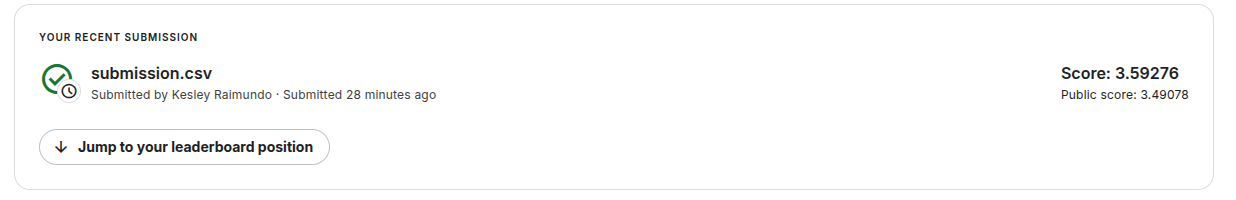

This is the AMS in the kaggle test set. Around 3.5 means that we have a significance of 3.5 sigma for the Higgs boson discovery.

Usally, a significance of 5 sigma is required to claim a discovery in particle physics. However, as it is, still means at least an evidence for the Higgs boson presence in the data.

# 11. References

1. **ATLAS Collaboration**, *Higgs Boson Machine Learning Challenge (HiggsML)* — official challenge documentation (referred to as **documentation.pdf** in this notebook).
2. **Bhat, P.** *Statistical Methods in Particle Physics* — background on likelihood‑ratio tests and significance.
3. **LightGBM**, **XGBoost** official docs — implementation details for handling missing values and sample weights.
4. **Optuna** documentation — hyperparameter optimization framework.